In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("05_pcb_planner_tny264/2025-12-23_08-54-28-772.csv")
df.head()

,CH1,CH2,time,Ts
0,-99.968750,0.019984,0.000000e+00,4.000000e-09
1,-97.984375,0.023953,4.000000e-09,NaN
2,-94.000000,0.024000,8.000000e-09,NaN
3,-100.000000,0.023953,1.200000e-08,NaN
4,-108.000000,0.021891,1.600000e-08,NaN


In [5]:
V0corr= pd.read_csv(r"./02_Power_spp_11V_Tny264_V2/2025-12-21_13-59-23-559.csv").CH1.mean()
V0corr

np.float64(-21.3888)

In [6]:
from utils import *
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [7]:
from sklearn.linear_model import LinearRegression as LR

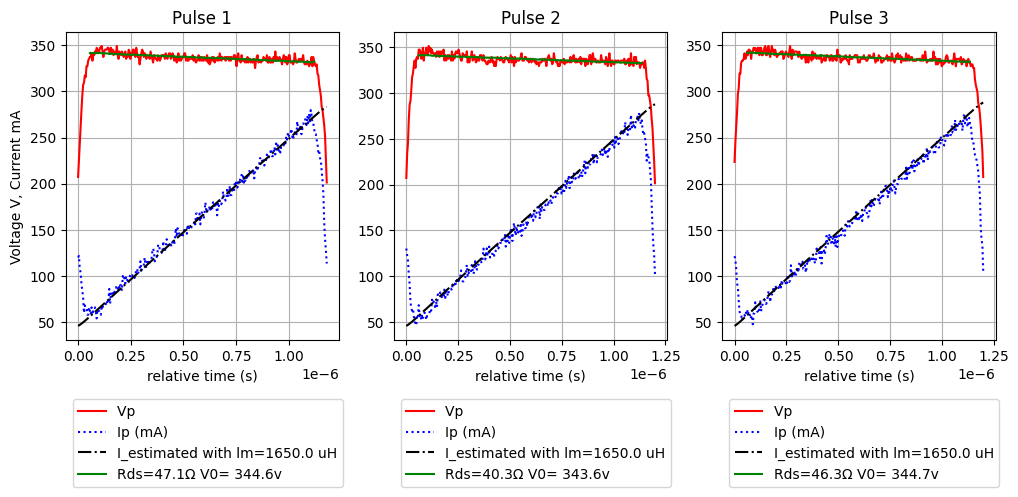

In [8]:
fig , axs = plt.subplots(1,3, figsize=(12,4))
axs = axs .flatten()

## df= pd.read_csv("2025-12-23_08-54-28-772.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values-V0corr
Ip = df.CH2.values
time = df.time.values
irise = trigger(Vp, 200,'rise')
ifall = trigger(Vp, 200,'fall')
Vin =340
k=1
colors=["C0","C1","C2"]
for i,j in zip(irise, ifall):
    N=500
    t=time[i-N:j]
    t=t-t[0]
    vp=Vp[i-N:j]
    ip=Ip[i-N:j]
    ip=ip-ip[:50].mean()
    t=t[N:]
    ip=ip[N:]
    vp=vp[N:]
    t=t-t[0]
    axs[k-1].plot(t,vp, label =f"Vp ", c=f"r")
    axs[k-1].plot(t,ip*1e3, label =f"Ip (mA)", linestyle="dotted", c=f"b")
    # v =L di/dt
    Lm=1650e-6
    ical= vp.cumsum()*Ts/Lm
    axs[k-1].plot(t,1e3*ical+45, c=f"k", label=f"I_estimated with lm={1e6*Lm:0.1f} uH"
             , linestyle='dashdot')
    axs[k-1].set_title(f"Pulse {k}")
    axs[k-1].grid()

    N=len(ip)
    ip = ip[int(0.05*N):int(0.95*N)]
    vp = vp[int(0.05*N):int(0.95*N)]
    x = ip.reshape(-1,1)
    y=vp
    model = LR().fit(x,y)
    Rds = -model.coef_
    V0= model.intercept_
    axs[k-1].plot(t[int(0.05*N):int(0.95*N)], V0-Rds*x, 
                  label = f"Rds={Rds[0]:0.1f}Ω V0= {V0:0.1f}v", 
                 c="g")
    #axs[k-1].legend()
    axs[k-1].legend(loc='lower left', bbox_to_anchor=(0, -0.5))
    axs[k-1].set_xlabel ("relative time (s)")

    


    
    k=k+1
axs[0].set_ylabel ("Voltage V, Current mA")
    
time = np.arange(0, len(Vp)*Ts, Ts)
fig.savefig("Tny264_345V_lm.png", bbox_inches="tight")



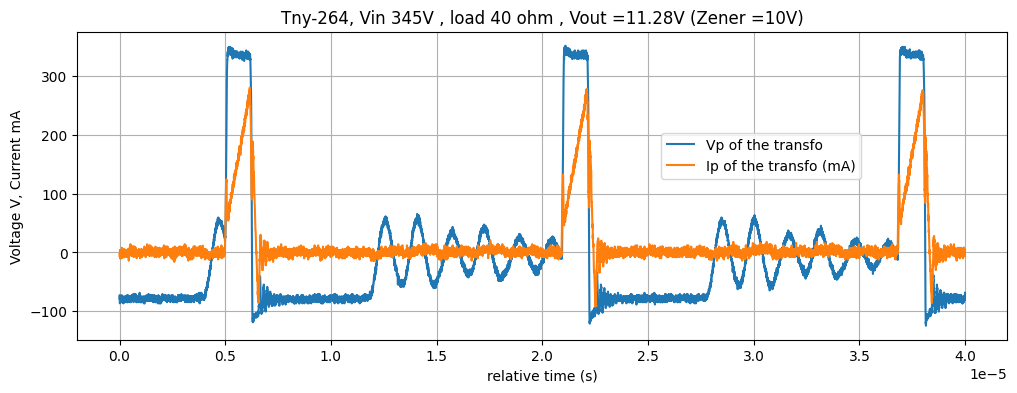

In [10]:
df= pd.read_csv("05_pcb_planner_tny264/2025-12-23_08-54-28-772.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values-V0corr
Ip = df.CH2.values
Ip = Ip-Ip[:500].mean()


time = np.arange(0, len(Vp)*Ts, Ts)
fig , axs = plt.subplots(1,1, figsize=(12,4))
plt.plot(time, Vp, label = "Vp of the transfo")
plt.plot(time, 1000*Ip, label = "Ip of the transfo (mA)")
plt.grid()
plt.legend(ncols=1,loc='lower right', bbox_to_anchor=(0.85, 0.5))
plt.ylabel ("Voltage V, Current mA")
plt.xlabel ("relative time (s)")
plt.title("Tny-264, Vin 345V , load 40 ohm , Vout =11.28V (Zener =10V)")
fig.savefig("Tny264_345V_time.png", bbox_inches="tight")

In [ ]:
from math import *

In [11]:
from math import *

In [12]:
from copy import copy
Vp0=copy(Vp )

0.6329113924050632 MHZ
6.060606060606056 MHZ


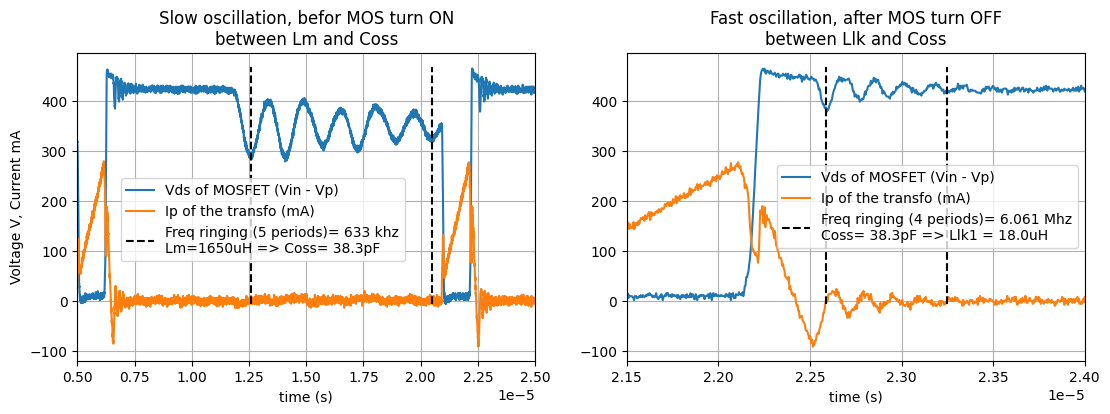

In [34]:
fig , axs = plt.subplots(1,2, figsize=(13,4))
axs = axs .flatten()
vin = 345

Vp=vin-copy(Vp0)
################
plt.sca(axs[0])

plt.plot(time, Vp, label = "Vds of MOSFET (Vin - Vp)")
Ip2= Ip-Ip[:200].mean()
plt.plot(time, 1000*Ip2, label = "Ip of the transfo (mA)")
plt.xlim([0.5e-5,2.5e-5])
x0=1.26e-5
x1=2.05e-5
plt.plot([x0,x0],[Vp.min(), Vp.max()], c="k", linestyle="--")


n=5
fring= n/(x1-x0)
print(fring*1e-6, "MHZ")
fring_lm= fring
Lm=1650
Coss= 1/ ((2*pi)**2*Lm*1e-6*fring_lm**2)

plt.plot([x1,x1],[Vp.min(), Vp.max()], c="k", linestyle="--",
         label = f"Freq ringing ({n} periods)= {fring*1e-3:.0f} khz"+\
         f"\nLm={Lm}uH => Coss= {Coss*1e12:0.1f}pF")



plt.grid()
plt.legend()
plt.title("Slow oscillation, befor MOS turn ON\nbetween Lm and Coss")



##################
plt.sca(axs[1])

plt.plot(time, Vp, label = "Vds of MOSFET (Vin - Vp)")
Ip2= Ip-Ip[:200].mean()
plt.plot(time, 1000*Ip2, label = "Ip of the transfo (mA)")
plt.xlim([0.6e-5,0.8e-5])
plt.xlim([2.15E-5,2.4E-5])
x0=2.259e-5
x1=2.325e-5
plt.plot([x0,x0],[Vp.min(), Vp.max()], c="k", linestyle="--")


n=4
fring= n/(x1-x0)
print(fring*1e-6, "MHZ")
Llk1 = 1/ ((2*pi)**2*Coss*fring**2)
plt.plot([x1,x1],[Vp.min(), Vp.max()], c="k", linestyle="--",
         label = f"Freq ringing ({n} periods)= {fring*1e-6:.3f} Mhz\n"+\
        f"Coss= {Coss*1e12:0.1f}pF => Llk1 = {Llk1*1e6:.1f}uH")
fring_lk= fring

plt.grid()
plt.legend()
plt.title("Fast oscillation, after MOS turn OFF\nbetween Llk and Coss")

axs[0].set_ylabel ("Voltage V, Current mA")
axs[0].set_xlabel ("time (s)")
axs[1].set_xlabel ("time (s)")

axs[0].legend(loc='lower left', bbox_to_anchor=(0.08, 0.3))
fig.savefig("Tny264_345V_Llk_coss.png", bbox_inches="tight")

In [27]:
n=5
fring= n/(x1-x0)
print(fring*1e-6, "MHZ")
fring_lm= fring
Lm=1650
Coss= 1/ ((2*pi)**2*Lm*1e-6*fring_lm**2)

0.6329113924050632 MHZ


In [33]:
t0=1.26e-05
t1= 2.05e-5
n=5
fring= n/(t1-t0)
print(fring*1e-6, "MHZ")
Lm=1650
Coss= 1/ ((2*pi)**2*Lm*1e-6*fring**2)


0.6329113924050632 MHZ


In [36]:
t0=2.259e-5
t1=2.325e-5


n=4
fring= n/(t1-t0)
print(fring*1e-6, "MHZ")
Llk1 = 1/ ((2*pi)**2*Coss*fring**2)

6.060606060606056 MHZ


In [37]:
# Vin out 350.6 11.28
# 2026-01-03_20-43-43-679.csv
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

,CH2,CH3,CH4,time,Ts
0,-0.007,1.9,57.6,0.000000e+00,1.000000e-08
1,-0.008,2.3,57.6,1.000000e-08,NaN
2,-0.007,1.7,58.8,2.000000e-08,NaN
3,-0.011,2.2,57.6,3.000000e-08,NaN
4,-0.010,2.3,57.6,4.000000e-08,NaN


np.float64(1e-08)

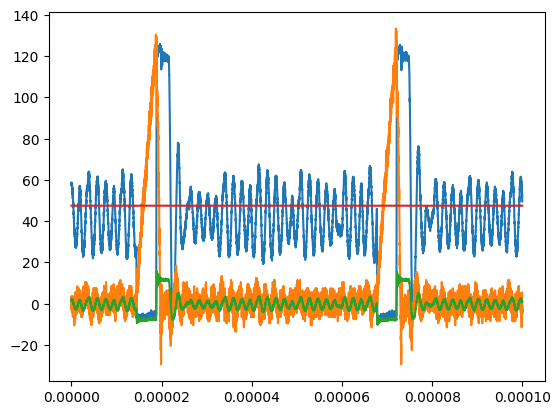

In [38]:
df= pd.read_csv("05_pcb_planner_tny264/2026-01-03_20-13-08-982.csv")
display(df.head())
Ts = df.Ts .values[0]
#Vp = 47.5-df.CH4.values
Vds = df.CH4.values
Ip = df.CH2.values
Vs = df.CH3.values
vin = 47.5
time = np.arange(0, len(Vds)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr
#Vds=Vds+5
plt.plot(time, Vds)

plt.plot(time, 1000*Ip)
plt.plot(time, Vs)
plt.plot(time, len(time)*[vin ])
Ts

43.400000000000006


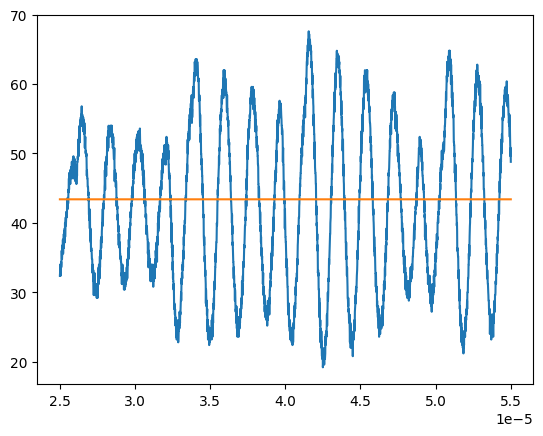

In [39]:
m= abs(time-40e-6)<15e-6
t= time[m]
v = Vds[m]
v0=(v.max()+v.min())/2
plt.plot(t,v )
plt.plot(t,len(t)*[v0] )
print(v0)

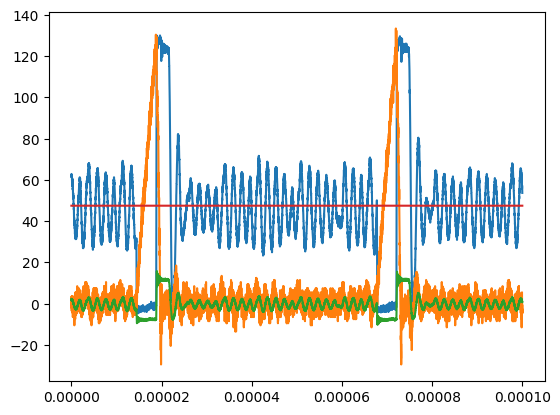

In [40]:
vds2=Vds-v0+vin
vp= vin -vds2
plt.plot(time, vds2)

plt.plot(time, 1000*Ip)
plt.plot(time, Vs)
plt.plot(time, len(time)*[vin ])

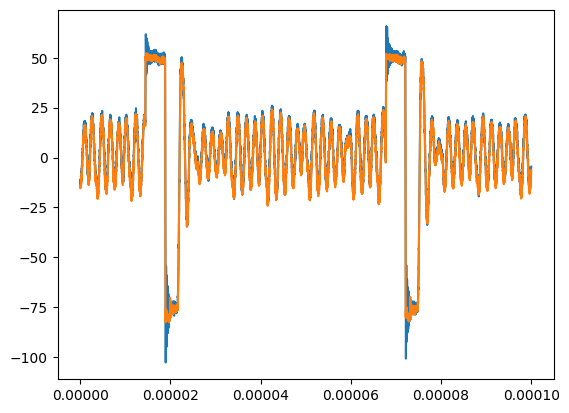

In [41]:
plt.plot(time, -Vs*26/4)
plt.plot(time, vp)

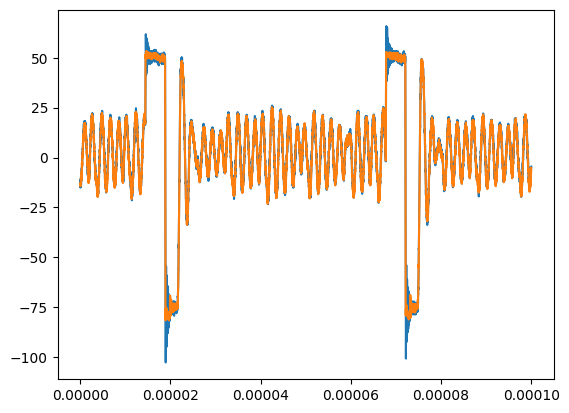

In [42]:
plt.plot(time, -Vs*26/4)
Vp = vp+1
plt.plot(time,Vp )

0.5675999999999999


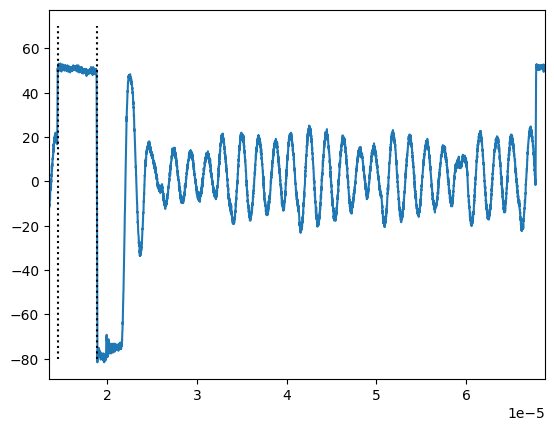

In [57]:
plt.plot(time,Vp ,label = "Vp of the transfo = Vin - Vds (v)")
t0=14.5e-6
t1=18.8e-6# 21.6e-6
plt.plot([t0,t0], [-80,70], c="k", linestyle= "dotted")
plt.plot([t1,t1], [-80,70], c="k", linestyle= "dotted")
plt.xlim([t0-1e-6,t1+50e-6])
dt=t1-t0
D= dt*132e3
print(D)

0.5675999999999999


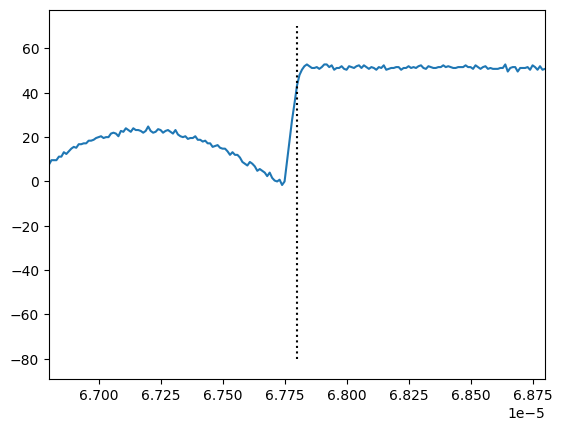

In [64]:
plt.plot(time,Vp ,label = "Vp of the transfo = Vin - Vds (v)")
t0=14.5e-6
t1=18.8e-6# 21.6e-6
t2= 67.8e-6
plt.plot([t0,t0], [-80,70], c="k", linestyle= "dotted")
plt.plot([t1,t1], [-80,70], c="k", linestyle= "dotted")
plt.plot([t2,t2], [-80,70], c="k", linestyle= "dotted")
plt.xlim([t1+48e-6,t1+50e-6])
dt=t1-t0
D= dt*132e3
print(D)

0.5675999999999999
0.5675999999999999


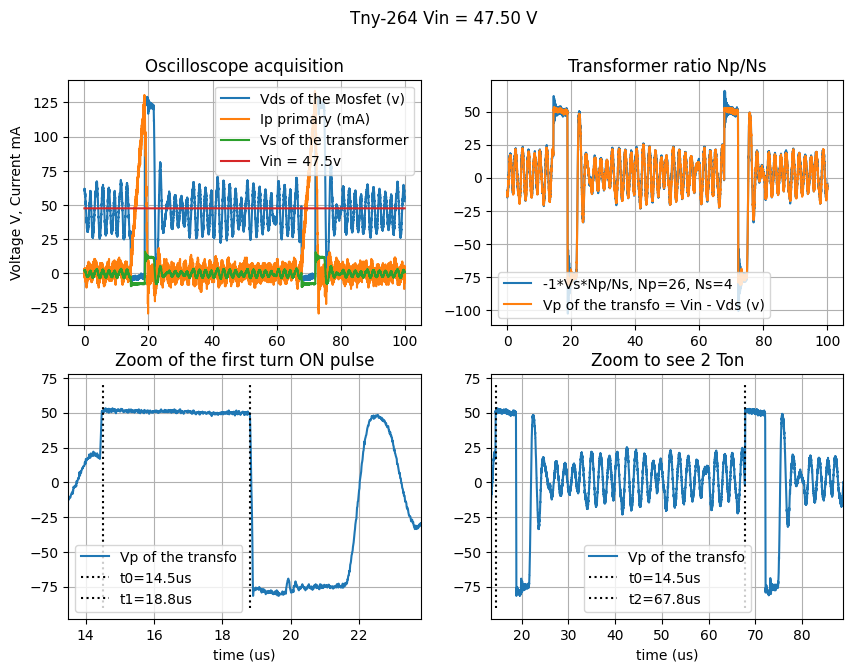

In [81]:
fig , axs = plt.subplots(2,2, figsize=(10,7))
axs = axs .flatten()

################
plt.sca(axs[0])

plt.plot(1e6*time, vin -Vp, label = "Vds of the Mosfet (v)")
plt.plot(1e6*time, 1000*Ip, label = "Ip primary (mA)")
plt.plot(1e6*time, Vs, label = "Vs of the transformer")
plt.plot(1e6*time, len(time)*[vin ], label = f"Vin = {vin}v")
plt.legend()
plt.grid()
plt.title('Oscilloscope acquisition')


plt.sca(axs[1])
plt.plot(1e6*time, -Vs*26/4,label = "-1*Vs*Np/Ns, Np=26, Ns=4")
plt.plot(1e6*time,Vp ,label = "Vp of the transfo = Vin - Vds (v)")
plt.legend()
plt.grid()
plt.title('Transformer ratio Np/Ns')





plt.sca(axs[2])
plt.plot(1e6*time,Vp ,label = "Vp of the transfo")
t0=14.5e-6
t1=18.8e-6# 21.6e-6
t2= 67.8e-6
plt.plot(1e6*np.array([t0,t0]), [-90,70], c="k", linestyle= "dotted",
         label = f"t0={t0*1e6}us")
plt.plot(1e6*np.array([t1,t1]), [-90,70], c="k", linestyle= "dotted", 
         label = f"t1={t1*1e6}us")

plt.xlim(1e6*np.array([t0-1e-6,t1+5e-6])  )

plt.legend()
plt.grid()
dt=t1-t0
D= dt*132e3
print(D)
plt.title(f'Zoom of the first turn ON pulse')






plt.sca(axs[3])
plt.plot(1e6*time,Vp ,label = "Vp of the transfo")
t0=14.5e-6
t1=18.8e-6# 21.6e-6
t2= 67.8e-6
plt.plot(1e6*np.array([t0,t0]), [-90,70], c="k", linestyle= "dotted",
         label = f"t0={t0*1e6}us")

plt.plot(1e6*np.array([t2,t2]), [-90,70], c="k", linestyle= "dotted", 
         label = f"t2={t2*1e6}us")
plt.xlim(1e6*np.array([t0-1e-6,t1+70e-6])  )

plt.legend()
plt.grid()
dt=t1-t0
D= dt*132e3
print(D)
plt.title(f'Zoom to see 2 Ton')






axs[0].set_ylabel ("Voltage V, Current mA")
#axs[0].set_xlabel ("time (us)")
#axs[1].set_xlabel ("time (us)")
axs[2].set_xlabel ("time (us)")
axs[3].set_xlabel ("time (us)")






#axs[0].legend(loc='lower left', bbox_to_anchor=(0.08, 0.3))
fig.suptitle("Tny-264 Vin = 47.50 V")
fig.savefig("Tny264_48V_time3.png", bbox_inches="tight")


In [91]:
from handcalcs import render

In [105]:
%%render 
t0=14.5 # µs 
t1=18.8 # µs
t2= 67.8 # µs
Ton = t1-t0 # µs
T = t2-t0 # µs
N_periode=7
Freq = N_periode/(T*1e-6)
Freq_khz = Freq*1e-3
Duty_cycle = 100*Ton*1e-6*Freq # \%

<IPython.core.display.Latex object>

In [93]:
7/(t2-t1)

0.14285714285714285

In [159]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


{'CH1': np.float64(-36.7106609375),
 'CH2': np.float64(-0.40513034375),
 'CH4': np.float64(-3.705905625)}

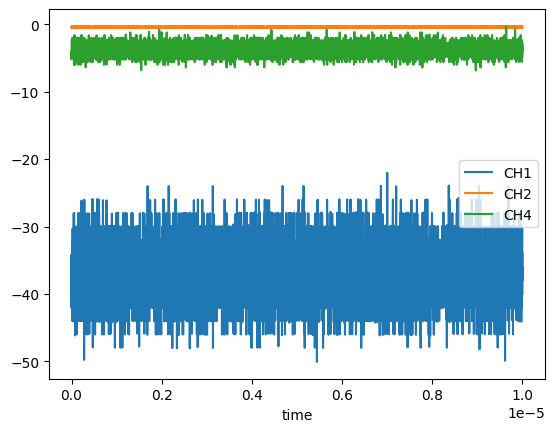

In [160]:
df0= pd.read_csv('06_tny_264_last_modifs/2026-01-06_17-17-57-819.csv')
df0.plot(x='time', y=['CH1','CH2','CH4'])
vals0={}
for c in ['CH1','CH2','CH4']: 
    vals0[c]=df0[c].mean() 
vals0

In [161]:
list_ = """351.2V
2026-01-06_17-43-30-844
377.5v
2026-01-06_17-45-21-093
401.9v
2026-01-06_17-46-24-611
427.4v
2026-01-06_17-48-22-544""".split("\n")
voltages = list_[::2][::-1]
files = list_[1::2][::-1]

In [162]:
from utils import *
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [163]:
import sklearn

In [164]:
Rds

44.567

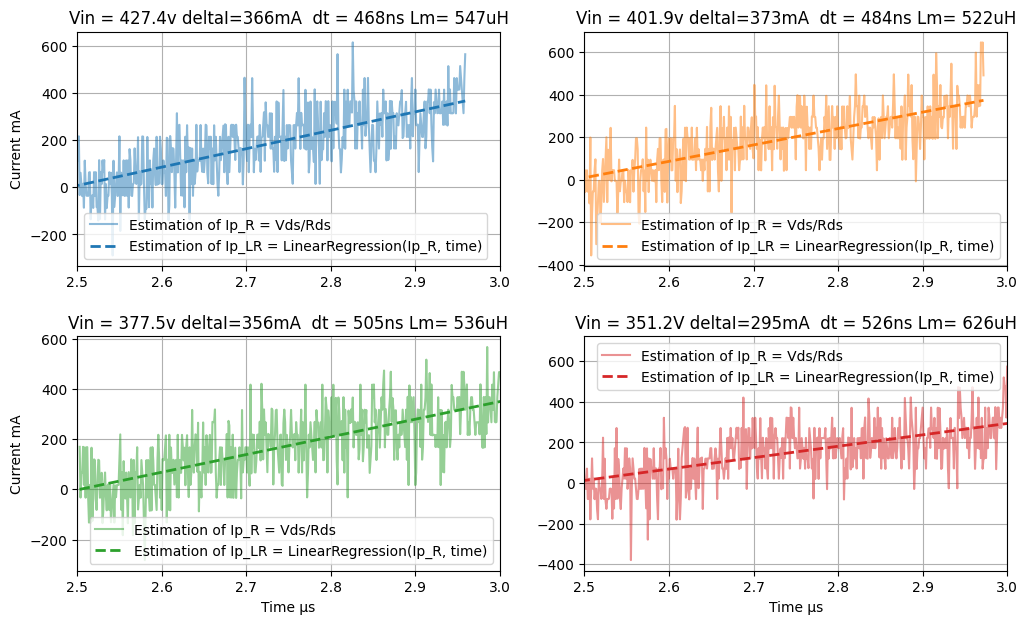

In [165]:
fig , axs = plt.subplots(2,2, figsize=(12,7))
fig.subplots_adjust(hspace=0.3)
axs = axs .flatten()
k=0
arr  = []
for vol, f in zip(voltages, files): 
    f="06_tny_264_last_modifs/"+f+".csv"
    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    Is= df.CH2.values-vals0["CH2"]
    time = df.time.values*1e6
    Is=Is-Is[:1000].mean()
    i= trigger(Vds, thresh=200, transition='fall')[0]+40
    j= trigger(Vds, thresh=200, transition='rise')[0]-60
    
    vds = Vds[i:j]
    t = time[i:j]
    m= sklearn.linear_model.LinearRegression()
    Rds =40
    m.fit(t.reshape((-1,1)),vds/Rds)
    ic=m.predict(t.reshape((-1,1)))
    iest=vds/Rds
    dt = t[-1]-t[0]
    di = ic[-1]-ic[0]
    V0= float(vol.lower().replace("v", ""))
    # v = L di/dt
    Lm= V0/(di/dt)
    
    axs[k].plot(t,1e3*(iest-ic[0]), label = f"Estimation of Ip_R = Vds/Rds", alpha = 0.5, c=f"C{k}")
    axs[k].plot(t,1e3*(ic-ic[0]), label =f"Estimation of Ip_LR = LinearRegression(Ip_R, time)",
             linestyle= "--", linewidth=2, c=f"C{k}")

    axs[k].set_title(f'Vin = {vol} deltaI={1e3*(ic.max()-ic.min()):0.0f}mA  dt = {1e3*dt:0.0f}ns Lm= {Lm:0.0f}uH')
    
    



    dic = {"Vin":float(vol.lower().replace("v","")),
           "dt_ns":1000*dt, 
           "di_mA": 1e3*(ic.max()-ic.min()), 
            "Lm_uH": Lm}
    arr.append(dic)
    axs[k].legend()
    axs[k].grid()
    axs[k].set_xlim([2.5,3])


    k=k+1

    
axs[0 ].set_ylabel("Current mA")
axs[2 ].set_ylabel("Current mA")
axs[2].set_xlabel("Time µs")
axs[3 ].set_xlabel("Time µs")


fig.savefig("Tny264_Estimation_of_lm2.png", bbox_inches="tight")

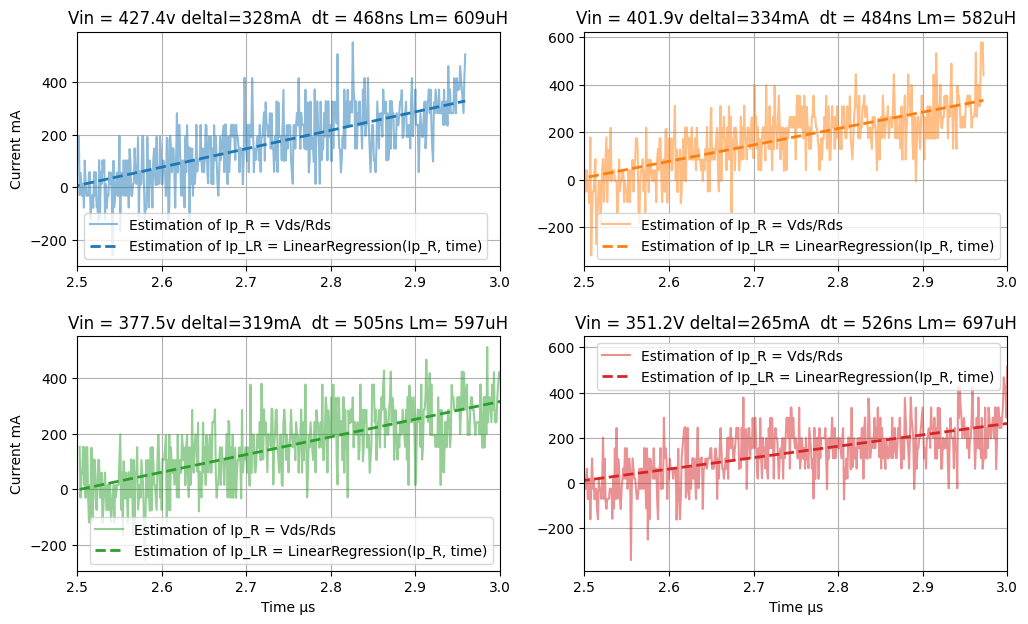

In [166]:

fig , axs = plt.subplots(2,2, figsize=(12,7))
fig.subplots_adjust(hspace=0.3)
axs = axs .flatten()
k=0
arr  = []
for vol, f in zip(voltages, files): 
    f="06_tny_264_last_modifs/"+f+".csv"
    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    Is= df.CH2.values-vals0["CH2"]
    time = df.time.values*1e6
    Is=Is-Is[:1000].mean()
    i= trigger(Vds, thresh=200, transition='fall')[0]+40
    j= trigger(Vds, thresh=200, transition='rise')[0]-60
    
    vds = Vds[i:j]
    t = time[i:j]
    m= sklearn.linear_model.LinearRegression()
    Rds =44.567
    m.fit(t.reshape((-1,1)),vds/Rds)
    ic=m.predict(t.reshape((-1,1)))
    iest=vds/Rds
    dt = t[-1]-t[0]
    di = ic[-1]-ic[0]
    V0= float(vol.lower().replace("v", ""))
    # v = L di/dt
    Lm= V0/(di/dt)
    
    axs[k].plot(t,1e3*(iest-ic[0]), label = f"Estimation of Ip_R = Vds/Rds", alpha = 0.5, c=f"C{k}")
    axs[k].plot(t,1e3*(ic-ic[0]), label =f"Estimation of Ip_LR = LinearRegression(Ip_R, time)",
             linestyle= "--", linewidth=2, c=f"C{k}")

    axs[k].set_title(f'Vin = {vol} deltaI={1e3*(ic.max()-ic.min()):0.0f}mA  dt = {1e3*dt:0.0f}ns Lm= {Lm:0.0f}uH')
    
    



    dic = {"Vin":float(vol.lower().replace("v","")),
           "dt_ns":1000*dt, 
           "di_mA": 1e3*(ic.max()-ic.min()), 
            "Lm_uH": Lm}
    arr.append(dic)
    axs[k].legend()
    axs[k].grid()
    axs[k].set_xlim([2.5,3])


    k=k+1

    
axs[0 ].set_ylabel("Current mA")
axs[2 ].set_ylabel("Current mA")
axs[2].set_xlabel("Time µs")
axs[3 ].set_xlabel("Time µs")


fig.savefig("Tny264_Estimation_of_lm3.png", bbox_inches="tight")

In [167]:
dfL=pd.DataFrame(arr).astype(int)
print(dfL.to_string(index=False))

 Vin  dt_ns  di_mA  Lm_uH
 427    468    328    609
 401    484    334    581
 377    505    319    596
 351    525    264    697


In [168]:
#%pip install tabulate

In [169]:
print(dfL.sort_values("Vin").to_markdown(index=False))

|   Vin |   dt_ns |   di_mA |   Lm_uH |
|------:|--------:|--------:|--------:|
|   351 |     525 |     264 |     697 |
|   377 |     505 |     319 |     596 |
|   401 |     484 |     334 |     581 |
|   427 |     468 |     328 |     609 |


|   Vin |   dt_ns |   di_mA |   Lm_uH |
|------:|--------:|--------:|--------:|
|   427 |     468 |     365 |     546 |
|   401 |     484 |     372 |     522 |
|   377 |     505 |     355 |     535 |
|   351 |     525 |     295 |     625 |

<Axes: xlabel='Vin'>

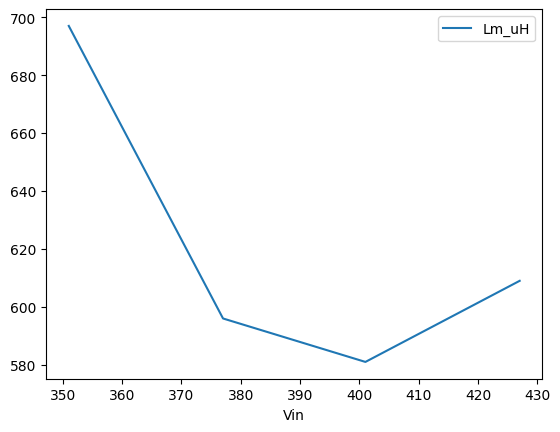

In [170]:
dfL.plot(x= "Vin", y= "Lm_uH")

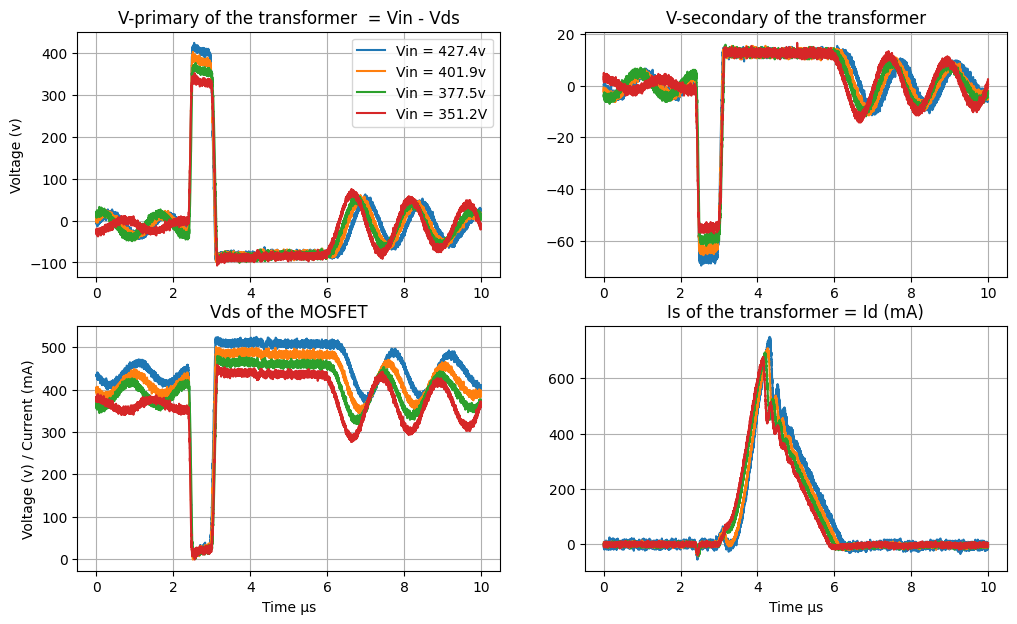

In [171]:
fig , axs = plt.subplots(2,2, figsize=(12,7))
axs = axs .flatten()
k=0
for vol, f in zip(voltages, files): 
    #f=f+".csv"
    f="06_tny_264_last_modifs/"+f+".csv"
    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    Is= df.CH2.values-vals0["CH2"]
    Is=Is-Is[:1000].mean()
    time = df.time.values*1e6

    V0= float(vol.lower().replace("v" ,""))

    axs[0].plot(time,V0- Vds, label = f"Vin = {vol}")
    axs[0 ].set_title("V-primary of the transformer  = Vin - Vds")

    axs[1].plot(time, Vs, label = f"Vin = {vol}")
    axs[1 ].set_title("V-secondary of the transformer")

    axs[2].plot(time, Vds, label = f"Vin = {vol}")
    axs[2 ].set_title("Vds of the MOSFET")

    axs[3].plot(time, 1000*Is, label = f"Vin = {vol}")
    axs[3 ].set_title("Is of the transformer = Id (mA)")




    #axs[k].legend()
    axs[k].grid()
    #axs[k].set_xlim([2.5,3])


    k=k+1

    
axs[0 ].set_ylabel("Voltage (v)")
axs[2 ].set_ylabel("Voltage (v) / Current (mA)")
axs[2].set_xlabel("Time µs")
axs[3 ].set_xlabel("Time µs")




    
#axs[0].legend()
#axs[3].legend()
#axs[3].legend(loc='upper left', bbox_to_anchor=(0, 1))
# Ensure a legend is created for axs[0]

# Get the handles and labels from axs[3]
handles, labels = axs[3].get_legend_handles_labels()

# Create the legend in axs[0] using the same handles and labels
axs[0].legend(handles, labels)  # Adjust loc as needed

fig.savefig("Tny264_time_meas2.png", bbox_inches="tight")

In [172]:
df

,CH1,CH2,CH4,time,Ts
0,343.953125,-0.054078,-1.200000,0.000000e+00,1.000000e-09
1,334.015625,-0.060203,1.190625,1.000000e-09,NaN
2,341.984375,-0.063875,-1.553125,2.000000e-09,NaN
3,338.000000,-0.054016,-2.462500,3.000000e-09,NaN
4,347.968750,-0.060125,-0.040625,4.000000e-09,NaN
...,...,...,...,...,...
9995,335.921875,-0.066000,-4.000000,9.995000e-06,NaN
9996,333.828125,-0.058859,-3.243750,9.996000e-06,NaN
9997,326.000000,-0.049984,-1.200000,9.997000e-06,NaN
9998,330.000000,-0.054000,-3.212500,9.998000e-06,NaN


In [173]:
0.7*4/26, 26*250/4

(0.10769230769230768, 1625.0)

In [174]:
vout2 =11.35
vd2 = 0.5
Vs0 = Vs[3500:4000].mean()
Vs0, vout2+vd2

(np.float64(12.666999375), 11.85)

1.1449999999999996 us


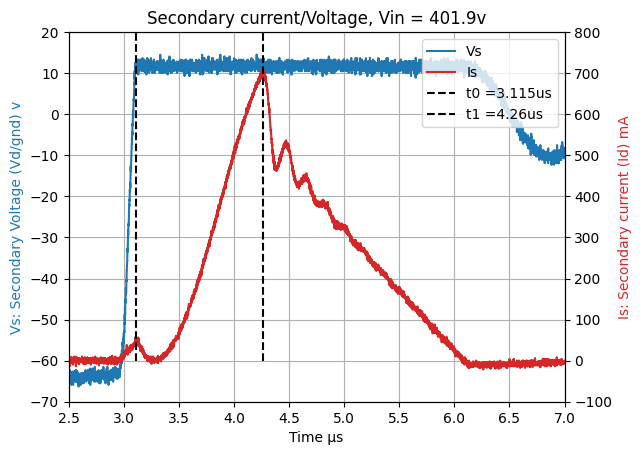

In [186]:
vol = "401.9v"
f= "06_tny_264_last_modifs/"+"2026-01-06_17-46-24-611"
f=f+".csv"
df= pd.read_csv(f)
Vds= df.CH1.values-vals0["CH1"]
Vs= df.CH4.values-vals0["CH4"]
Vs = Vs - Vs0 + (vout2+vd2)
Is= df.CH2.values-vals0["CH2"]
Is=Is-Is[:1000].mean()
time = df.time.values*1e6

V0= float(vol.lower().replace("v" ,""))


fig, ax = plt.subplots()
ax.plot(time, Vs, label = f"Vs", color='C0')
ax2 = ax.twinx()
ax2.plot(time, 1e3*Is, label = f"Is", color='C3')
ax.set_xlim([2.5,7])
t0=3.115
t1=4.26
dt=t1-t0
print(dt,"us")
ax2.plot([t0,t0],[0,800], c="k", linestyle = "--", label=f"t0 ={t0}us")
ax2.plot([t1,t1],[0,800], c="k", linestyle = "--", label=f"t1 ={t1}us")
#plt.plot(time, 1e2*Is, label = f"Vin = {vol}")


ax.set_ylabel('Vs: Secondary Voltage (Vd/gnd) v', color='C0')
ax2.set_ylabel('Is: Secondary current (Id) mA', color='C3')

ax.set_ylim([ -70, 20])
ax2.set_ylim([ -100,800 ])

ax.grid()
ax.set_xlabel ("Time µs")

lines = ax.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels)
ax.set_title("Secondary current/Voltage, Vin = "+vol)
fig.savefig("Tny264_zoom_Is.png", bbox_inches="tight")

In [230]:
for vol, f in zip(voltages, files): 
    print(vol, f )

427.4v 2026-01-06_17-48-22-544
401.9v 2026-01-06_17-46-24-611
377.5v 2026-01-06_17-45-21-093
351.2V 2026-01-06_17-43-30-844


In [234]:

f= "06_tny_264_last_modifs/"+"2026-01-06_17-43-30-844"
f=f+".csv"
df= pd.read_csv(f)
Vds= df.CH1.values-vals0["CH1"]
Vs= df.CH4.values-vals0["CH4"]
Vs = Vs - Vs0 + (vout2+vd2)
Is= df.CH2.values-vals0["CH2"]
Is=Is-Is[:1000].mean()
time = df.time.values*1e6

In [235]:
import numpy as np
from scipy.signal import butter, filtfilt

# Example 1D signal
fs =1/df.Ts.iloc[0]
#time =df.time.values
x = Vds  # signal + high freq noise

# Filter parameters
cutoff = 10e6  # cutoff frequency (Hz)
order = 2    # 2nd order filter

# Normalize cutoff (Nyquist = fs/2)
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq

# Design Butterworth filter
b, a = butter(order, normal_cutoff, btype='low', analog=False)

# Apply zero-phase filtering
y = filtfilt(b, a, x)

In [236]:
#Is= df.CH2.values-vals0["CH2"]
#Is=Is-Is[:1000].mean()

Text(0.5, 1.0, 'Butterworth Low-Pass Filter')

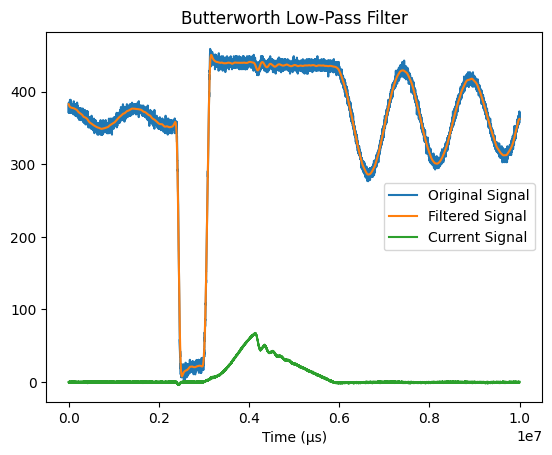

In [237]:
plt.plot(1e6*time, x, label='Original Signal')
plt.plot(1e6*time , y, label='Filtered Signal')
plt.plot(1e6*time , 1e2*Is, label='Current Signal')
plt.legend()
plt.xlabel('Time (µs)')
plt.title('Butterworth Low-Pass Filter')   


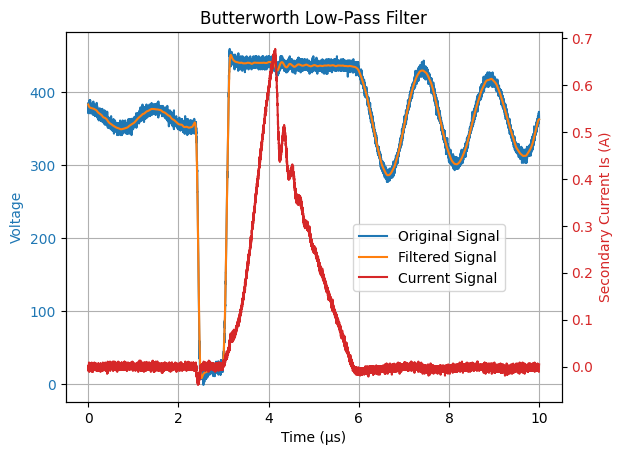

(0.0, 500.0)

In [241]:

fig, ax1 = plt.subplots()

ax1.plot( time, x, label='Original Signal', color='C0')
ax1.plot( time, y, label='Filtered Signal', color='C1')
ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('Voltage', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(time,  Is, label='Current Signal', color='C3')
ax2.set_ylabel("Secondary Current Is (A)", color='C3')
ax2.tick_params(axis='y', labelcolor='C3')



lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best', bbox_to_anchor=(0.9, 0.5))

plt.title('Butterworth Low-Pass Filter')
plt.show()

t_plot = 1e6 * time if np.max(time) < 1e-3 else time
x_label = "Time (µs)" if np.max(time) < 1e-3 else "Time"

voltage = Vs if "Vs" in globals() else Vp
current = Is if "Is" in globals() else Ip

ax1.plot(t_plot, voltage, color="C0", label="Vs")
ax1.set_xlabel(x_label)
ax1.set_ylabel("Vds Voltage (V)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.grid()


ax2.set_ylim([0, 1])
ax1.set_ylim([0, 500])


(-50.0, 500.0)

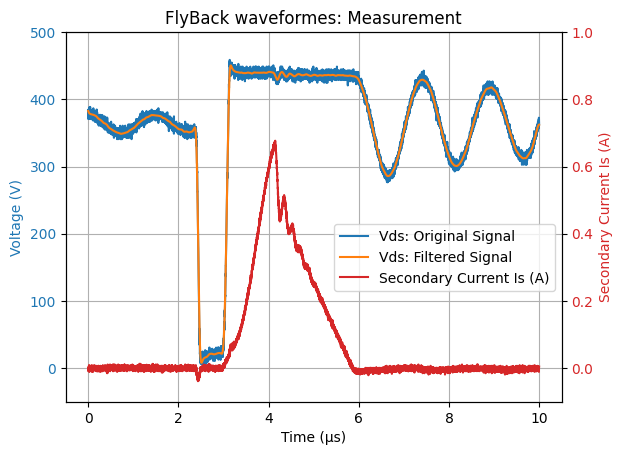

In [247]:

fig, ax1 = plt.subplots()

ax1.plot( time, x, label='Vds: Original Signal', color='C0')
ax1.plot( time, y, label='Vds: Filtered Signal', color='C1')
ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('Voltage (V)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(time,  Is, label='Secondary Current Is (A)', color='C3')
ax2.set_ylabel("Secondary Current Is (A)", color='C3')
ax2.tick_params(axis='y', labelcolor='C3')



lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best', bbox_to_anchor=(1, 0.5))

plt.title('FlyBack waveformes: Measurement')



ax2.set_ylim([-0.1, 1])
ax1.set_ylim([-50, 500])


In [ ]:
print(dfL.sort_values("Vin").to_markdown(index=False))

|   Vin |   dt_ns |   di_mA |   Lm_uH |
|------:|--------:|--------:|--------:|
|   351 |     525 |     264 |     697 |
|   377 |     505 |     319 |     596 |
|   401 |     484 |     334 |     581 |
|   427 |     468 |     328 |     609 |


1.1750000000000003 us


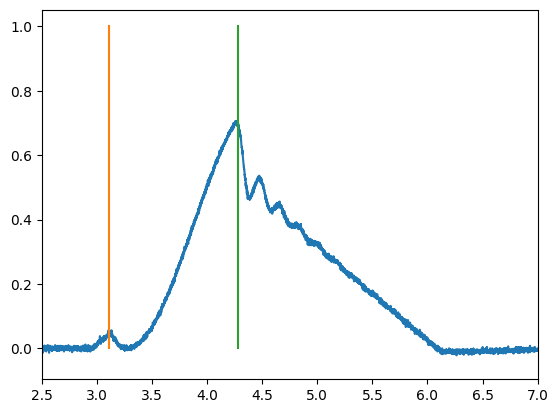

In [180]:
plt.plot(time, Is, label = f"Vin = {vol}")
plt.xlim([2.5,7])
t0=3.11
t1=4.285
dt=t1-t0
print(dt,"us")
plt.plot([t0,t0],[0,1])
plt.plot([t1,t1],[0,1])

In [178]:

df= pd.read_csv('2026-01-06_18-10-59-970.csv')
time = df.time.values
Vout = df.CH4.values

df.plot(x="time",y="CH4")

FileNotFoundError: [Errno 2] No such file or directory: '2026-01-06_18-10-59-970.csv'

In [ ]:
df.Ts.iloc[0]*10e3

np.float64(0.02)

270
610
880


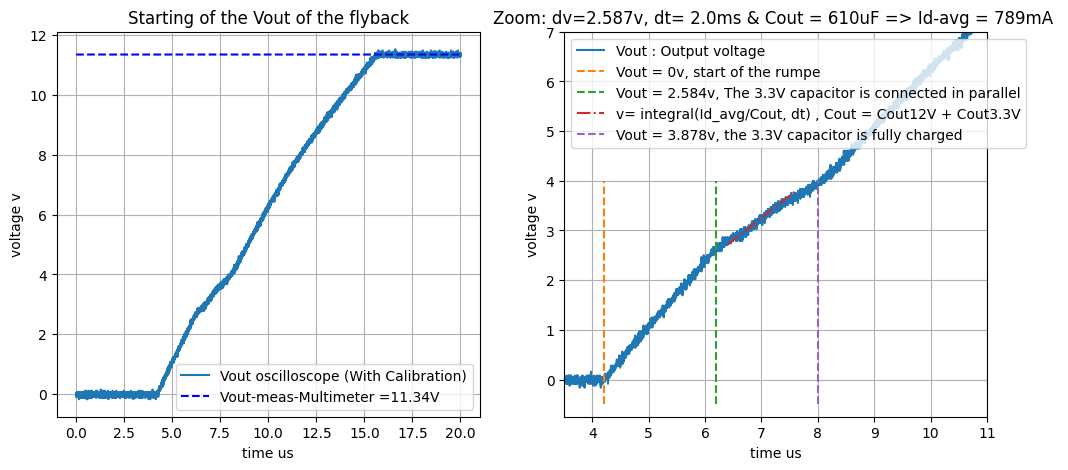

In [ ]:
C33=220+10+10*4
print(C33)
Cout = 470+10+100+10+10+10
Cout
print(Cout)
Cout2=Cout+C33
print(Cout2)


fig , axs = plt.subplots(1,2, figsize=(12,5))
axs = axs .flatten()


VoutMes= 11.34
Vout = Vout-Vout[:1000].mean()

Vf= Vout[-1000:].mean()
Vout = VoutMes*Vout/Vf
axs[0].plot(time*1e3, Vout, label = "Vout oscilloscope (With Calibration)")
axs[0].plot(time*1e3, [VoutMes]*len(Vout),linestyle = "--", c="b", label="Vout-meas-Multimeter =11.34V")
axs[0].grid()
axs[0].legend()
axs[0].set_xlabel("time us")
axs[0].set_ylabel("voltage v")
axs[0].set_title("Starting of the Vout of the flyback")







plt.plot(time*1e3, Vout, label= "Vout : Output voltage")
plt.grid()

plt.xlim([3.5, 11])
plt.ylim([None, 7])

t0=4.2
t1=6.2

i= np.argmin(np.abs(time*1e3-t0))
j= np.argmin(np.abs(time*1e3-t1))
dv = Vout[j]-Vout[i]
dt= t1-t0


plt.plot([t0,t0],[-0.5,4], label = "Vout = 0v, start of the rumpe"
    ,linestyle = "--")
plt.plot([t1,t1],[-0.5,4], label = f"Vout = {Vout[j]:.3f}v, The 3.3V capacitor is connected in parallel"
    ,linestyle = "--")

Iout = 1e3 * Cout*1e-6*dv/(dt*1e-3) #  i = c dv/dt
plt.title(f"Zoom: dv={dv:.3f}v, dt= {dt:.1f}ms & Cout = {Cout}uF => Id-avg = {Iout:0.0f}mA ")




# i = c dv/dt
v2 = (Iout*1e-3/(Cout2*1e-6))*(time-t1*1e-3)+Vout[j]-0.05
t=time*1e3
m= t>t1+0.2
t=t[m]
v2=v2[m]
plt.plot(t[:600], v2[:600], label = "v= integral(Id_avg/Cout, dt) , Cout = Cout12V + Cout3.3V"
         ,linestyle = "dashdot")
t2=8
K= np.argmin(np.abs(time*1e3-t2))
plt.plot([t2,t2],[-0.5,4], label = f"Vout = {Vout[K]:.3f}v, the 3.3V capacitor is fully charged "
    ,linestyle = "--")
#plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.xlabel("time us")
plt.ylabel("voltage v")
fig.savefig("Tny264_Vout_start.png", bbox_inches="tight")

In [ ]:
# Vdp = 5.877 5.878

In [ ]:
C33

270

In [ ]:
Iout = 1e3 * Cout*1e-6*dv/(dt*1e-3) #  i = c dv/dt
Iout, Cout, dv, dt

(np.float64(789.0157833953549), 610, np.float64(2.5869369947388687), 2.0)

In [ ]:
t

array([ 6.402,  6.404,  6.406, ..., 19.994, 19.996, 19.998], shape=(6799,))

In [ ]:
dtp=600e-9 # vin=345
Freq =132e3
DC=Freq*dtp 
DC, "DutyCy"

(0.07919999999999999, 'DutyCy')

In [ ]:

Np, Ns =26,4
#IpAvg=Freq*Iinpeak *dtp/2
#IsAvg=Iout
#Is = Np/Ns Ip 
#Iout  =   Np/Ns * Freq*Iinpeak *dtp/2 # DC=Freq*dtp
Iinpeak = Iout  *(Ns/Np)/(DC/2)
Iinpeak  # Nok i expect

np.float64(3065.329383820338)

In [ ]:
Np/Ns * Freq*Iinpeak *dtp/2

np.float64(789.015783395355)

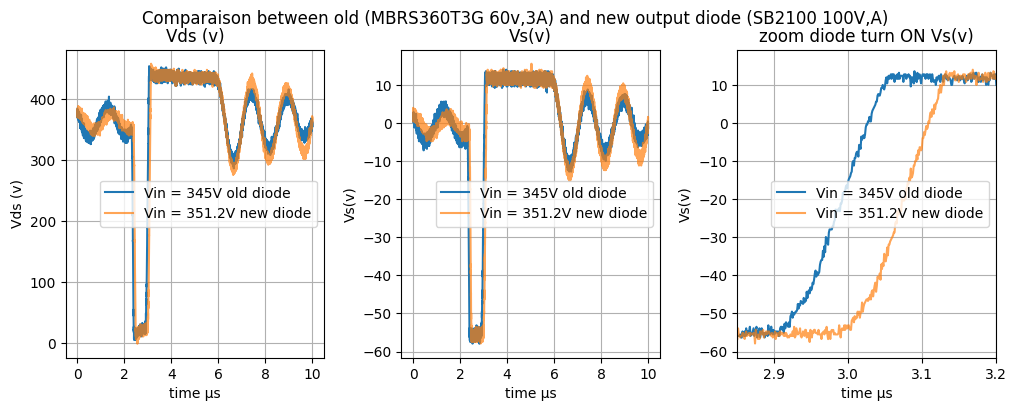

In [ ]:
fig , axs = plt.subplots(1,3, figsize=(12,4))
fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(hspace=0.3)
axs = axs .flatten()
k=0
alp=1
for f, lab in  zip (
        (#"2026-01-06_15-58-48-465.csv",
         "2026-01-06_17-16-25-122.csv",
         "2026-01-06_17-43-30-844.csv"), 
         ( "Vin = 345V old diode",#"Vin = 345V old diode (MBRS360T3G 60v,3A)", 
          "Vin = 351.2V new diode") # "Vin = 351.2V new diode (SB2100 100V,A)"
    ): 
    if k==1:
        alp=0.7

    df= pd.read_csv(f)
    Vds= df.CH1.values-vals0["CH1"]
    Vs= df.CH4.values-vals0["CH4"]
    time =df.time.values*1e6
    Vs = Vs - Vs0 + (vout2+vd2)
    Is= df.CH2.values-vals0["CH2"]
    Is=Is-Is[:1000].mean()
    axs[0].plot(time, Vds, label = lab, c=f"C{k}",alpha = alp)
    axs[1].plot(time, Vs, label = lab, c=f"C{k}",alpha = alp)
    #axs[2].plot(time, Is, label = lab, c=f"C{k}")
    axs[2].plot(time, Vs, label = lab, c=f"C{k}",alpha = alp)
    axs[2].set_xlim([2.85,3.2])

    k=k+1
axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[0].grid()
axs[1].grid()
axs[2].grid()
axs[0].set_xlabel("time µs")
axs[1].set_xlabel("time µs")
axs[2].set_xlabel("time µs")

axs[0].set_ylabel("Vds (v)")
axs[1].set_ylabel("Vs(v)")
axs[2].set_ylabel("Vs(v)")

axs[0].set_title("Vds (v)")
axs[1].set_title("Vs(v)")
axs[2].set_title("zoom diode turn ON Vs(v)")
fig.suptitle("Comparaison between old (MBRS360T3G 60v,3A) and new output diode (SB2100 100V,A)")

fig.savefig("Tny264_change_out_diode.png", bbox_inches="tight")